In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

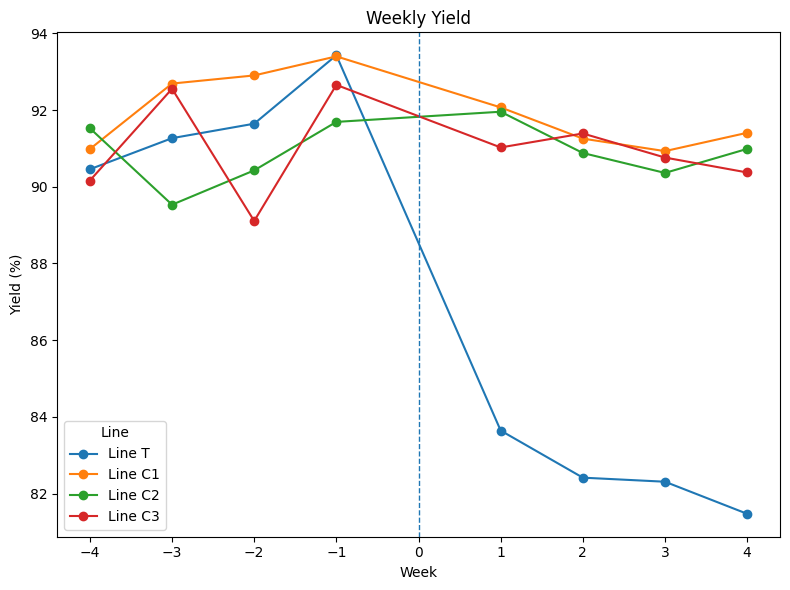

In [2]:
np.random.seed(42)

lines = ["T", "C1", "C2", "C3"]
weeks = [-4, -3, -2, -1, 1, 2, 3, 4]
n_weeks = len(weeks)

baseline_pre = {"T": 0.920, "C1": 0.920, "C2": 0.910, "C3": 0.901}
baseline_post = {"T": 0.820, "C1": 0.917, "C2": 0.905, "C3": 0.905}

rows = []
for line in lines:
    for w in weeks:
        phase = "pre" if w<0 else "post"
        total = np.random.randint(600, 1000)
        if phase == "pre":
            mu = baseline_pre[line]+np.random.normal(0, 0.003)
        else:
            mu = baseline_post[line]+np.random.normal(0, 0.004)
        mu = float(np.clip(mu, 0.6, 0.999))
        defect_rate = 1.0-mu
        defects = np.random.binomial(total, defect_rate)
        yield_rate = 1.0-defects/total
        rows.append({
            "line": line,
            "phase": phase,
            "week_rel": w,
            "total_wafers": total,
            "defect_wafers": defects,
            "yield_rate": yield_rate
        })

df = pd.DataFrame(rows).sort_values(["line", "week_rel"]).reset_index(drop=True)

plt.figure(figsize=(8, 6))
for line in lines:
    sub = df[df["line"] == line]
    sub = sub.sort_values("week_rel")
    plt.plot(sub["week_rel"], 100*sub["yield_rate"], marker='o', label=f"Line {line}")

plt.axvline(x=0, linestyle='--', linewidth=1)
plt.title("Weekly Yield")
plt.xlabel("Week")
plt.ylabel("Yield (%)")
plt.legend(title="Line", loc="lower left")
plt.tight_layout()
plt.show()


In [3]:
rows

[{'line': 'T',
  'phase': 'pre',
  'week_rel': -4,
  'total_wafers': 702,
  'defect_wafers': 67,
  'yield_rate': 0.9045584045584045},
 {'line': 'T',
  'phase': 'pre',
  'week_rel': -3,
  'total_wafers': 687,
  'defect_wafers': 60,
  'yield_rate': 0.9126637554585153},
 {'line': 'T',
  'phase': 'pre',
  'week_rel': -2,
  'total_wafers': 730,
  'defect_wafers': 61,
  'yield_rate': 0.9164383561643835},
 {'line': 'T',
  'phase': 'pre',
  'week_rel': -1,
  'total_wafers': 913,
  'defect_wafers': 60,
  'yield_rate': 0.9342825848849945},
 {'line': 'T',
  'phase': 'post',
  'week_rel': 1,
  'total_wafers': 648,
  'defect_wafers': 106,
  'yield_rate': 0.8364197530864197},
 {'line': 'T',
  'phase': 'post',
  'week_rel': 2,
  'total_wafers': 870,
  'defect_wafers': 153,
  'yield_rate': 0.8241379310344827},
 {'line': 'T',
  'phase': 'post',
  'week_rel': 3,
  'total_wafers': 650,
  'defect_wafers': 115,
  'yield_rate': 0.823076923076923},
 {'line': 'T',
  'phase': 'post',
  'week_rel': 4,
  'total_

In [4]:
pre = df[df["phase"]=="pre"][["line","week_rel","yield_rate"]].rename(columns={"yield_rate":"p_pre"})
post = df[df["phase"]=="post"][["line","week_rel","yield_rate"]].rename(columns={"yield_rate":"p_post"})

pre = pre.copy()
pre["w_index"] = pre["week_rel"].abs()
post = post.copy()
post["w_index"] = post["week_rel"].abs()

paired = pd.merge(
    pre[["line","w_index","p_pre"]],
    post[["line","w_index","p_post"]],
    on=["line","w_index"],
    how="inner"
)

# Compute weekly deltas for each line
paired["Delta"] = paired["p_post"] - paired["p_pre"]

# Split by lines
T = paired[paired["line"]=="T"].copy()
C1 = paired[paired["line"]=="C1"].copy()
C2 = paired[paired["line"]=="C2"].copy()
C3 = paired[paired["line"]=="C3"].copy()

# Ensure weeks alignment
weeks = sorted(T["w_index"].unique())

# Build a per-week table
week_rows = []
for w in weeks:
    row = {"week": int(w)}
    # T pre/post and delta
    t_pre = pre[(pre["line"]=="T") & (pre["w_index"]==w)]["p_pre"].values[0]
    t_post = post[(post["line"]=="T") & (post["w_index"]==w)]["p_post"].values[0]
    t_delta = T[T["w_index"]==w]["Delta"].values[0]
    row.update({
        "T_pre": t_pre, "T_post": t_post, "Delta_T": t_delta
    })
    # control deltas
    dc1 = C1[C1["w_index"]==w]["Delta"].values[0]
    dc2 = C2[C2["w_index"]==w]["Delta"].values[0]
    dc3 = C3[C3["w_index"]==w]["Delta"].values[0]
    dbar = np.mean([dc1, dc2, dc3])
    row.update({
        "Delta_C1": dc1, "Delta_C2": dc2, "Delta_C3": dc3, "Delta_C_bar": dbar,
        "d_w": t_delta - dbar
    })
    week_rows.append(row)

week_table = pd.DataFrame(week_rows)
# Format percentages
def pct(x): return 100*x

display_week = week_table.copy()
for col in ["T_pre","T_post","Delta_T","Delta_C1","Delta_C2","Delta_C3","Delta_C_bar","d_w"]:
    display_week[col] = pct(display_week[col])

# Compute summary statistics on d_w
d = week_table["d_w"].values
n = len(d)
mean_d = np.mean(d)
sd_d = np.std(d, ddof=1)
se_d = sd_d/np.sqrt(n)
dfree = n-1
t_stat = mean_d / se_d if se_d>0 else np.nan
p_value = stats.t.cdf(t_stat, df=dfree)  # one-sided (greater)
# 95% two-sided CI for tau_hat
tcrit = stats.t.ppf(0.975, df=dfree)
ci_low = mean_d - tcrit*se_d
ci_high = mean_d + tcrit*se_d

summary = pd.DataFrame({
    "n_weeks":[n],
    "mean_Delta_T_pp":[pct(week_table["Delta_T"].mean())],
    "mean_Delta_Cbar_pp":[pct(week_table["Delta_C_bar"].mean())],
    "tau_hat_pp":[pct(mean_d)],
    "sd_d_pp":[pct(sd_d)],
    "t_statistic":[t_stat],
    "df":[dfree],
    "p_value_one_sided":[p_value],
    "CI_low_pp":[pct(ci_low)],
    "CI_high_pp":[pct(ci_high)]
})

summary


,n_weeks,mean_Delta_T_pp,mean_Delta_Cbar_pp,tau_hat_pp,sd_d_pp,t_statistic,df,p_value_one_sided,CI_low_pp,CI_high_pp
0,4,-9.239865,-0.353511,-8.886354,0.63646,-27.924311,3,0.00005,-9.899104,-7.873604


In [5]:
week_table

,week,T_pre,T_post,Delta_T,Delta_C1,Delta_C2,Delta_C3,Delta_C_bar,d_w
0,1,0.934283,0.836420,-0.097863,-0.013309,0.002653,-0.016311,-0.008989,-0.088874
1,2,0.916438,0.824138,-0.092300,-0.016475,0.004527,0.022815,0.003622,-0.095923
2,3,0.912664,0.823077,-0.089587,-0.017619,0.008286,-0.017939,-0.009090,-0.080497
3,4,0.904558,0.814714,-0.089845,0.004235,-0.005388,0.002103,0.000316,-0.090161
